In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

In [ ]:
train_woe = pd.read_csv('/content/train_woe.csv')

test_woe = pd.read_csv('/content/test_woe.csv')

In [ ]:
X_train = train_woe.drop(columns=['TARGET'])

y_train = train_woe['TARGET']

In [ ]:
X_test = test_woe.drop(columns=['TARGET'])

y_test = test_woe['TARGET']

In [ ]:
X_train = X_train.select_dtypes(exclude='object')
X_test = X_test.select_dtypes(exclude='object')

In [ ]:
X_train.isnull().sum().sort_values(ascending=False).head(20)

,0
NAME_EDUCATION_TYPE_woe,1
LIVINGAREA_AVG_woe,1
REGION_POPULATION_RELATIVE_woe,1
NAME_INCOME_TYPE_woe,1
FLAG_DOCUMENT_3_woe,1
ENTRANCES_MEDI_woe,1
APARTMENTS_AVG_woe,1
CREDIT_INCOME_RATIO_woe,1
EXT_SOURCE_2_woe,1
DAYS_REGISTRATION_woe,1


In [ ]:
X_train = X_train.fillna(0)

X_test = X_test.fillna(0)

In [ ]:
X_train.isnull().sum().sum()

np.int64(0)

In [ ]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
#probability predictions
lr_pred_prob = lr_model.predict_proba(X_test)[:,1]

In [ ]:
#class prediction
lr_pred_class = lr_model.predict(X_test)

In [ ]:
#calculate AUC
lr_auc = roc_auc_score(
    y_test,
    lr_pred_prob
)

print("Logistic Regression AUC:", lr_auc)

Logistic Regression AUC: 0.7412258515495442


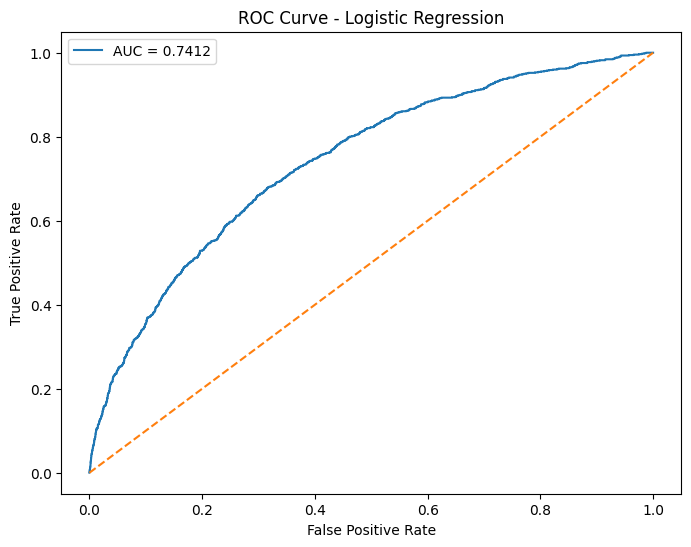

In [ ]:
#plot ROC
fpr, tpr, thresholds = roc_curve(
    y_test,
    lr_pred_prob
)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'AUC = {lr_auc:.4f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

In [ ]:
#KS function create
def ks_stat(y_true, y_pred):

    data = pd.DataFrame({
        'target': y_true,
        'score': y_pred
    })

    data = data.sort_values(
        by='score'
    )

    data['good'] = 1 - data['target']
    data['bad'] = data['target']

    data['cum_good'] = (
        data['good'].cumsum() /
        data['good'].sum()
    )

    data['cum_bad'] = (
        data['bad'].cumsum() /
        data['bad'].sum()
    )

    ks = max(
        abs(
            data['cum_good'] -
            data['cum_bad']
        )
    )

    return ks

In [ ]:
#calculate KS
lr_ks = ks_stat(
    y_test,
    lr_pred_prob
)

print("Logistic Regression KS:", lr_ks)

Logistic Regression KS: 0.36282599691908257


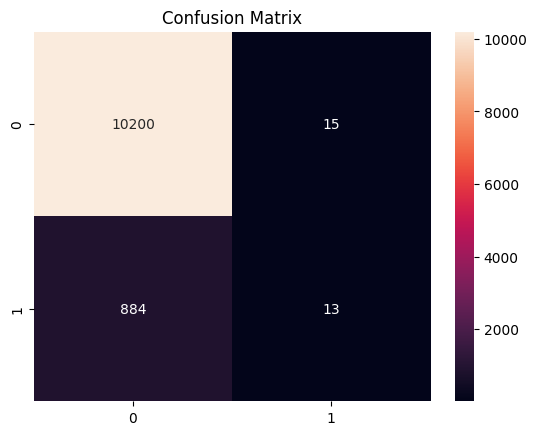

In [ ]:
#Confusion Matrix
cm = confusion_matrix(
    y_test,
    lr_pred_class
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

In [ ]:
#Classification Report
print(
    classification_report(
        y_test,
        lr_pred_class
    )
)

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     10215
           1       0.46      0.01      0.03       897

    accuracy                           0.92     11112
   macro avg       0.69      0.51      0.49     11112
weighted avg       0.88      0.92      0.88     11112



In [ ]:
#feature importance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

importance.head(20)

,Feature,Coefficient
43,NAME_CONTRACT_TYPE_woe,1.024875
68,EXT_SOURCE_3_woe,0.846843
77,YEARS_BEGINEXPLUATATION_MODE_woe,0.785259
58,ANNUITY_INCOME_RATIO_woe,0.765304
72,EXT_SOURCE_2_woe,0.675308
67,CREDIT_TERM_woe,0.658781
83,ORGANIZATION_TYPE_woe,0.584462
56,EXT_SOURCE_1_woe,0.583949
69,DAYS_EMPLOYED_woe,0.567032
76,FLOORSMAX_AVG_woe,0.559800


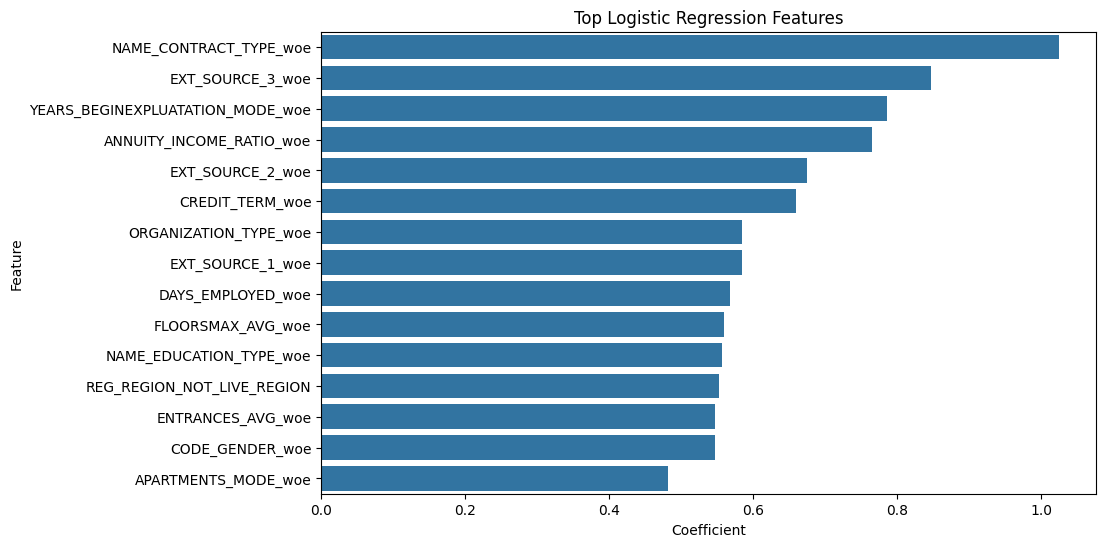

In [ ]:
# Visualize feature importance

top_features = importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=top_features
)

plt.title("Top Logistic Regression Features")

plt.show()

In [ ]:
#Build XGBoost Model

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#XG boost Predictions
xgb_pred_prob = xgb_model.predict_proba(X_test)[:,1]

In [ ]:
#XGboost AUC
xgb_auc = roc_auc_score(
    y_test,
    xgb_pred_prob
)

print("XGBoost AUC:", xgb_auc)

XGBoost AUC: 0.7390930556033027


In [ ]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'AUC': [lr_auc, xgb_auc]
})

comparison

,Model,AUC
0,Logistic Regression,0.741226
1,XGBoost,0.739093


In [ ]:
import joblib

joblib.dump(lr_model, 'lr_model.pkl')

['lr_model.pkl']